from typing_extensions import runtime
#Task 1: Google cloud Environment Setup

I created a Google Cloud project and used Colab Enterprise
to run mt Jupyter notebook on a managed cloud runtime the
runtime uses an e2-standard-4 machine without a GPU

In [1]:
import sys
import platform

print("Python Version:", sys.version)
print("Operating system:", platform.system())
print("Processor:",platform.machine())

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Operating system: Linux
Processor: x86_64


#Task 2: Loading the UCI air quality dataset
In this task i will retrieve the air quality dataset from the UCI machine learning repo and load it into a pandas dataframe

In [2]:
import pandas as pd

df = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")

df.head()


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


#Task 3: Data inspection
In this task, I will examine the dataset's structure, data types, and summary statistics using pandas

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


In [4]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,NaN,NaN


#Task 4:Identifying and handling missing vaues
The data set contains missing measurements that are represented by "-200" I will identify these values and prepare the dataset.

In [5]:
(df == -200).sum()

,0
Date,0
Time,0
CO(GT),1683
PT08.S1(CO),366
NMHC(GT),8443
C6H6(GT),366
PT08.S2(NMHC),366
NOx(GT),1639
PT08.S3(NOx),366
NO2(GT),1642


In [6]:
df_clean = df.drop(columns=["Unnamed: 15", "Unnamed: 16"])

df_clean = df_clean.dropna(subset=["Date", "Time"])

print(df_clean.shape)

(9357, 15)


In [7]:
import numpy as np

numeric_columns = df_clean.select_dtypes(include="number").columns

df_clean[numeric_columns] = df_clean[numeric_columns].replace(-200, np.nan)

In [8]:
df_clean.isnull().sum()

,0
Date,0
Time,0
CO(GT),1683
PT08.S1(CO),366
NMHC(GT),8443
C6H6(GT),366
PT08.S2(NMHC),366
NOx(GT),1639
PT08.S3(NOx),366
NO2(GT),1642


In [11]:
print(df_clean.shape)
print(df_clean.columns.tolist())

(9357, 14)
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


In [12]:
print(df_clean.shape)
print(df_clean.isnull().sum())

(9357, 14)
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [13]:
df_model = df_clean.dropna(subset=["CO(GT)"]).copy()

print(df_model.shape)

(7674, 14)


In [14]:
X = df_model.drop(columns=["CO(GT)", "Date", "Time"])

y = df_model["CO(GT)"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7674, 11)
y shape: (7674,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (6139, 11)
X_test: (1535, 11)
y_train: (6139,)
y_test: (1535,)


#Task 5: Feature Preprocessing
In this task I will use Scikit-Learn's pipeline and columntransformer to prepare the data for machine learning. I will use SimpleImputer to fill in missing numerican values using the median and StandardScaler to scale the numerical features. I will also extract the hour from the Time column and use OneHotEncoder to convert it into categorical features. Finally, i will combine these steps into a ColumnTransformer and apply the preprocessing to the training and testing data.

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print(numeric_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [17]:
from sklearn.compose import ColumnTransformer

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features)
])

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)',
                                  'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)',
                                  'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH',
                                  'AH'])])


In [18]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (6139, 11)
Testing shape: (1535, 11)


In [19]:
import numpy as np

print("Training missing values:", np.isnan(X_train_processed).sum())
print("Testing missing values:", np.isnan(X_test_processed).sum())

Training missing values: 0
Testing missing values: 0


In [20]:
df_model[["Date", "Time"]].head(10)

,Date,Time
0,10/03/2004,18.00.00
1,10/03/2004,19.00.00
2,10/03/2004,20.00.00
3,10/03/2004,21.00.00
4,10/03/2004,22.00.00
5,10/03/2004,23.00.00
6,11/03/2004,00.00.00
7,11/03/2004,01.00.00
8,11/03/2004,02.00.00
9,11/03/2004,03.00.00


In [21]:
df_model["Hour"] = pd.to_datetime(
    df_model["Time"],
    format="%H.%M.%S"
).dt.hour

print(df_model[["Time", "Hour"]].head(10))

       Time  Hour
0  18.00.00    18
1  19.00.00    19
2  20.00.00    20
3  21.00.00    21
4  22.00.00    22
5  23.00.00    23
6  00.00.00     0
7  01.00.00     1
8  02.00.00     2
9  03.00.00     3


In [22]:
X = df_model.drop(columns=["CO(GT)", "Date", "Time"])
y = df_model["CO(GT)"]

X["Hour"] = X["Hour"].astype(str)

print(X.shape)
print(X["Hour"].head())

(7674, 12)
0    18
1    19
2    20
3    21
4    22
Name: Hour, dtype: object


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (6139, 12)
X_test: (1535, 12)


In [24]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print(categorical_pipeline)

Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))])


In [25]:
from sklearn.compose import ColumnTransformer

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = ["Hour"]

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)',
                                  'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)',
                                  'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH',
                                  'AH']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Hour'])])


In [26]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (6139, 35)
Testing shape: (1535, 35)


In [27]:
import numpy as np

print("Training missing values:",
      np.isnan(X_train_processed).sum())

print("Testing missing values:",
      np.isnan(X_test_processed).sum())

Training missing values: 0
Testing missing values: 0


#Task 6: Classification Models
In this task I will train classification models to predict air quality categories using carbon monoxide measurements. I will first convert the coninuous CO values into three categories: Low,Moderate, and High, using target binning. I will then train and compare logistic regression, softmax regression, and SGDClassifier models. I will evaluate their performance using classification metrics and compare their training convergence.

In [28]:
import pandas as pd
import numpy as np

# Find category boundaries using training data only
_, bins = pd.qcut(
    y_train,
    q=3,
    retbins=True,
    duplicates="drop"
)

print("Category boundaries:", bins)

Category boundaries: [ 0.1  1.4  2.5 11.9]


In [31]:
# Extend the boundaries to cover all CO measurements
bins[0] = -np.inf
bins[-1] = np.inf

# Convert training measurements into categories
y_train_class = pd.cut(
    y_train,
    bins=bins,
    labels=[0, 1, 2]
).astype(int)

# Convert testing measurements using the same boundaries
y_test_class = pd.cut(
    y_test,
    bins=bins,
    labels=[0, 1, 2]
).astype(int)

print("Training categories:")
print(y_train_class.value_counts().sort_index())

print("\nTesting categories:")
print(y_test_class.value_counts().sort_index())

Training categories:
CO(GT)
0    2241
1    1906
2    1992
Name: count, dtype: int64

Testing categories:
CO(GT)
0    661
1    473
2    401
Name: count, dtype: int64


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train_class)

print("Logistic Regression training complete!")

Logistic Regression training complete!


In [33]:
y_pred = logistic_model.predict(X_test)

print("Predicted:", y_pred[:10])
print("Actual:", y_test_class.iloc[:10].values)

Predicted: [0 0 0 0 0 0 0 0 0 0]
Actual: [0 0 0 0 0 0 0 0 0 0]


In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_class, y_pred)

print("Logistic Regression Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Logistic Regression Accuracy: 0.857328990228013
Accuracy Percentage: 85.7328990228013


In [35]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_class,
    y_pred,
    target_names=["Low", "Moderate", "High"]
))

              precision    recall  f1-score   support

         Low       0.91      0.86      0.89       661
    Moderate       0.76      0.82      0.79       473
        High       0.90      0.89      0.89       401

    accuracy                           0.86      1535
   macro avg       0.86      0.86      0.86      1535
weighted avg       0.86      0.86      0.86      1535



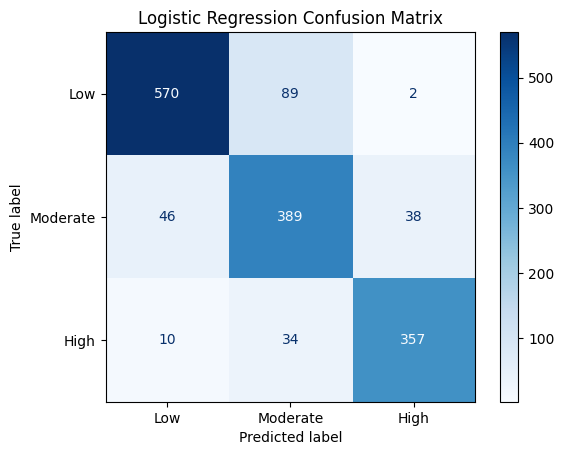

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_class, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Moderate", "High"]
)

display.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [37]:
iterations = logistic_model.named_steps["classifier"].n_iter_

print("Iterations needed:", iterations)

Iterations needed: [78]


In [38]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline

sgd_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SGDClassifier(
        loss="log_loss",
        alpha=0.0001,
        max_iter=1000,
        random_state=42
    ))
])

sgd_model.fit(X_train, y_train_class)

print("SGDClassifier training complete!")

SGDClassifier training complete!


In [39]:
from sklearn.metrics import accuracy_score, classification_report

sgd_pred = sgd_model.predict(X_test)

sgd_accuracy = accuracy_score(y_test_class, sgd_pred)

print("SGDClassifier Accuracy:", sgd_accuracy)
print("SGDClassifier Accuracy Percentage:", sgd_accuracy * 100)

print("\nClassification Report:")
print(classification_report(
    y_test_class,
    sgd_pred,
    target_names=["Low", "Moderate", "High"]
))

SGDClassifier Accuracy: 0.8371335504885994
SGDClassifier Accuracy Percentage: 83.71335504885994

Classification Report:
              precision    recall  f1-score   support

         Low       0.93      0.80      0.86       661
    Moderate       0.69      0.89      0.78       473
        High       0.95      0.83      0.89       401

    accuracy                           0.84      1535
   macro avg       0.86      0.84      0.84      1535
weighted avg       0.86      0.84      0.84      1535



In [40]:
sgd_iterations = sgd_model.named_steps["classifier"].n_iter_

print("SGDClassifier iterations:", sgd_iterations)

SGDClassifier iterations: 34


In [41]:
softmax_probabilities = logistic_model.predict_proba(X_test)

print("First 5 probability predictions:")
print(softmax_probabilities[:5])

print("\nClasses:", logistic_model.named_steps["classifier"].classes_)

First 5 probability predictions:
[[9.99733756e-01 2.66217571e-04 2.62924571e-08]
 [9.92893516e-01 7.10149302e-03 4.99072301e-06]
 [9.55100942e-01 4.47883131e-02 1.10744527e-04]
 [9.40560142e-01 5.93087143e-02 1.31144076e-04]
 [9.12505195e-01 8.73468253e-02 1.47979766e-04]]

Classes: [0 1 2]


In [42]:
probability_df = pd.DataFrame(
    softmax_probabilities[:5],
    columns=["Low", "Moderate", "High"]
)

print((probability_df * 100).round(2))

     Low  Moderate  High
0  99.97      0.03  0.00
1  99.29      0.71  0.00
2  95.51      4.48  0.01
3  94.06      5.93  0.01
4  91.25      8.73  0.01


In [43]:
import time
from sklearn.base import clone

# Time Logistic Regression
logistic_test = clone(logistic_model)

start = time.perf_counter()
logistic_test.fit(X_train, y_train_class)
logistic_time = time.perf_counter() - start

# Time SGDClassifier
sgd_test = clone(sgd_model)

start = time.perf_counter()
sgd_test.fit(X_train, y_train_class)
sgd_time = time.perf_counter() - start

print("Logistic Regression:", round(logistic_time, 4), "seconds")
print("SGDClassifier:", round(sgd_time, 4), "seconds")

Logistic Regression: 0.5754 seconds
SGDClassifier: 0.2356 seconds


In [44]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

sgd_hinge = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SGDClassifier(
        loss="hinge",
        alpha=0.0001,
        max_iter=1000,
        random_state=42
    ))
])

sgd_hinge.fit(X_train, y_train_class)

hinge_pred = sgd_hinge.predict(X_test)

print("SGD Hinge Accuracy:",
      accuracy_score(y_test_class, hinge_pred))

SGD Hinge Accuracy: 0.8312703583061889


In [45]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

# Copy our numerical pipeline and replace StandardScaler
minmax_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

# Build preprocessing with MinMaxScaler
minmax_preprocessor = ColumnTransformer([
    ("num", minmax_numeric, numeric_features),
    ("cat", clone(categorical_pipeline), categorical_features)
])

# Train the same SGD model using MinMaxScaler
sgd_minmax = Pipeline([
    ("preprocessor", minmax_preprocessor),
    ("classifier", SGDClassifier(
        loss="log_loss",
        alpha=0.0001,
        max_iter=1000,
        random_state=42
    ))
])

sgd_minmax.fit(X_train, y_train_class)

minmax_pred = sgd_minmax.predict(X_test)

print("MinMaxScaler Accuracy:",
      accuracy_score(y_test_class, minmax_pred))

print("MinMaxScaler Epochs:",
      sgd_minmax.named_steps["classifier"].n_iter_)

MinMaxScaler Accuracy: 0.8234527687296417
MinMaxScaler Epochs: 34


#Task 7:Regression Models
In this task, I will train regression models to predict continuous carbon monoxide concentrations using the air quality dataset. I will begin with Linear Regression as a baseline model. Then I will implement Ridge and Lasso Regression to examine how regularization affects model performance and feature coefficients. I will compare the models using regression evaluation metrics and experiment with different regularization strengths.

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)

print("Linear Regression training complete!")

Linear Regression training complete!


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, linear_pred)
rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
r2 = r2_score(y_test, linear_pred)

print("Linear Regression MAE:", mae)
print("Linear Regression RMSE:", rmse)
print("Linear Regression R²:", r2)

Linear Regression MAE: 0.30418812966161196
Linear Regression RMSE: 0.4799264984732005
Linear Regression R²: 0.8725862471485138


In [48]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

print("Ridge Regression training complete!")

Ridge Regression training complete!


In [49]:
ridge_pred = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MAE:", ridge_mae)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge MAE: 0.30424899247566345
Ridge RMSE: 0.4799082567171381
Ridge R²: 0.8725959328251086


In [50]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline

lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso(
        alpha=0.01,
        max_iter=10000
    ))
])

lasso_model.fit(X_train, y_train)

print("Lasso Regression training complete!")

Lasso Regression training complete!


In [51]:
lasso_pred = lasso_model.predict(X_test)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso MAE:", lasso_mae)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R²:", lasso_r2)

Lasso MAE: 0.33353976379748324
Lasso RMSE: 0.5100906201396243
Lasso R²: 0.8560666201703084


In [52]:
from sklearn.base import clone
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
import numpy as np

alphas = [0.001, 0.01, 0.1, 1.0]

for alpha in alphas:
    model = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("regressor", Lasso(alpha=alpha, max_iter=20000))
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    score = r2_score(y_test, predictions)

    coefficients = model.named_steps["regressor"].coef_
    zero_coefficients = np.sum(np.isclose(coefficients, 0, atol=1e-8))

    print(
        f"Alpha: {alpha} | "
        f"R²: {score:.4f} | "
        f"Zero coefficients: {zero_coefficients}"
    )

Alpha: 0.001 | R²: 0.8717 | Zero coefficients: 5
Alpha: 0.01 | R²: 0.8561 | Zero coefficients: 23
Alpha: 0.1 | R²: 0.8357 | Zero coefficients: 31
Alpha: 1.0 | R²: 0.3213 | Zero coefficients: 34


In [54]:
from sklearn.linear_model import Ridge
from sklearn.base import clone
from sklearn.metrics import r2_score
import numpy as np

alphas = [0.001, 0.01, 0.1, 1.0]

for alpha in alphas:
    model = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("regressor", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    score = r2_score(y_test, predictions)

    coefficients = model.named_steps["regressor"].coef_
    zero_coefficients = np.sum(np.isclose(coefficients, 0, atol=1e-8))

    print(
        f"Alpha: {alpha} | "
        f"R²: {score:.4f} | "
        f"Zero coefficients: {zero_coefficients}"
    )

Alpha: 0.001 | R²: 0.8726 | Zero coefficients: 0
Alpha: 0.01 | R²: 0.8726 | Zero coefficients: 0
Alpha: 0.1 | R²: 0.8726 | Zero coefficients: 0
Alpha: 1.0 | R²: 0.8726 | Zero coefficients: 0


In [55]:
import pandas as pd
import numpy as np

feature_names = lasso_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = lasso_model.named_steps[
    "regressor"
].coef_

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

selected_features = coefficient_df[
    ~np.isclose(coefficient_df["Coefficient"], 0, atol=1e-8)
]

print(selected_features.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
))

              Feature  Coefficient
3        num__NOx(GT)     0.513294
1       num__C6H6(GT)     0.506759
6   num__PT08.S4(NO2)     0.322149
0    num__PT08.S1(CO)     0.247516
22       cat__Hour_19     0.179915
24       cat__Hour_20     0.149227
10            num__AH    -0.147978
21       cat__Hour_18     0.069783
5        num__NO2(GT)     0.062210
7    num__PT08.S5(O3)    -0.030037
4   num__PT08.S3(NOx)     0.008298
8              num__T    -0.005835


In [56]:
from sklearn.linear_model import Ridge
from sklearn.base import clone
import numpy as np

ridge_alphas = [0.1, 1, 10, 100, 1000]

for alpha in ridge_alphas:
    model = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("regressor", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    score = r2_score(y_test, predictions)

    coefs = model.named_steps["regressor"].coef_

    print(
        f"Alpha: {alpha} | "
        f"R²: {score:.4f} | "
        f"Coefficient norm: {np.linalg.norm(coefs):.4f}"
    )

Alpha: 0.1 | R²: 0.8726 | Coefficient norm: 1.4747
Alpha: 1 | R²: 0.8726 | Coefficient norm: 1.4624
Alpha: 10 | R²: 0.8725 | Coefficient norm: 1.3648
Alpha: 100 | R²: 0.8694 | Coefficient norm: 1.0420
Alpha: 1000 | R²: 0.8458 | Coefficient norm: 0.6763


#Task 8: Google Cloud Resource Documentation:
In this task I will document the google cloud resources used to complete the machine learning experiments. I will capture evidence from the google cloud console showing my colab enterprise environment qnd the billing or resource usage information. This will show proof that the notebook was executed using a 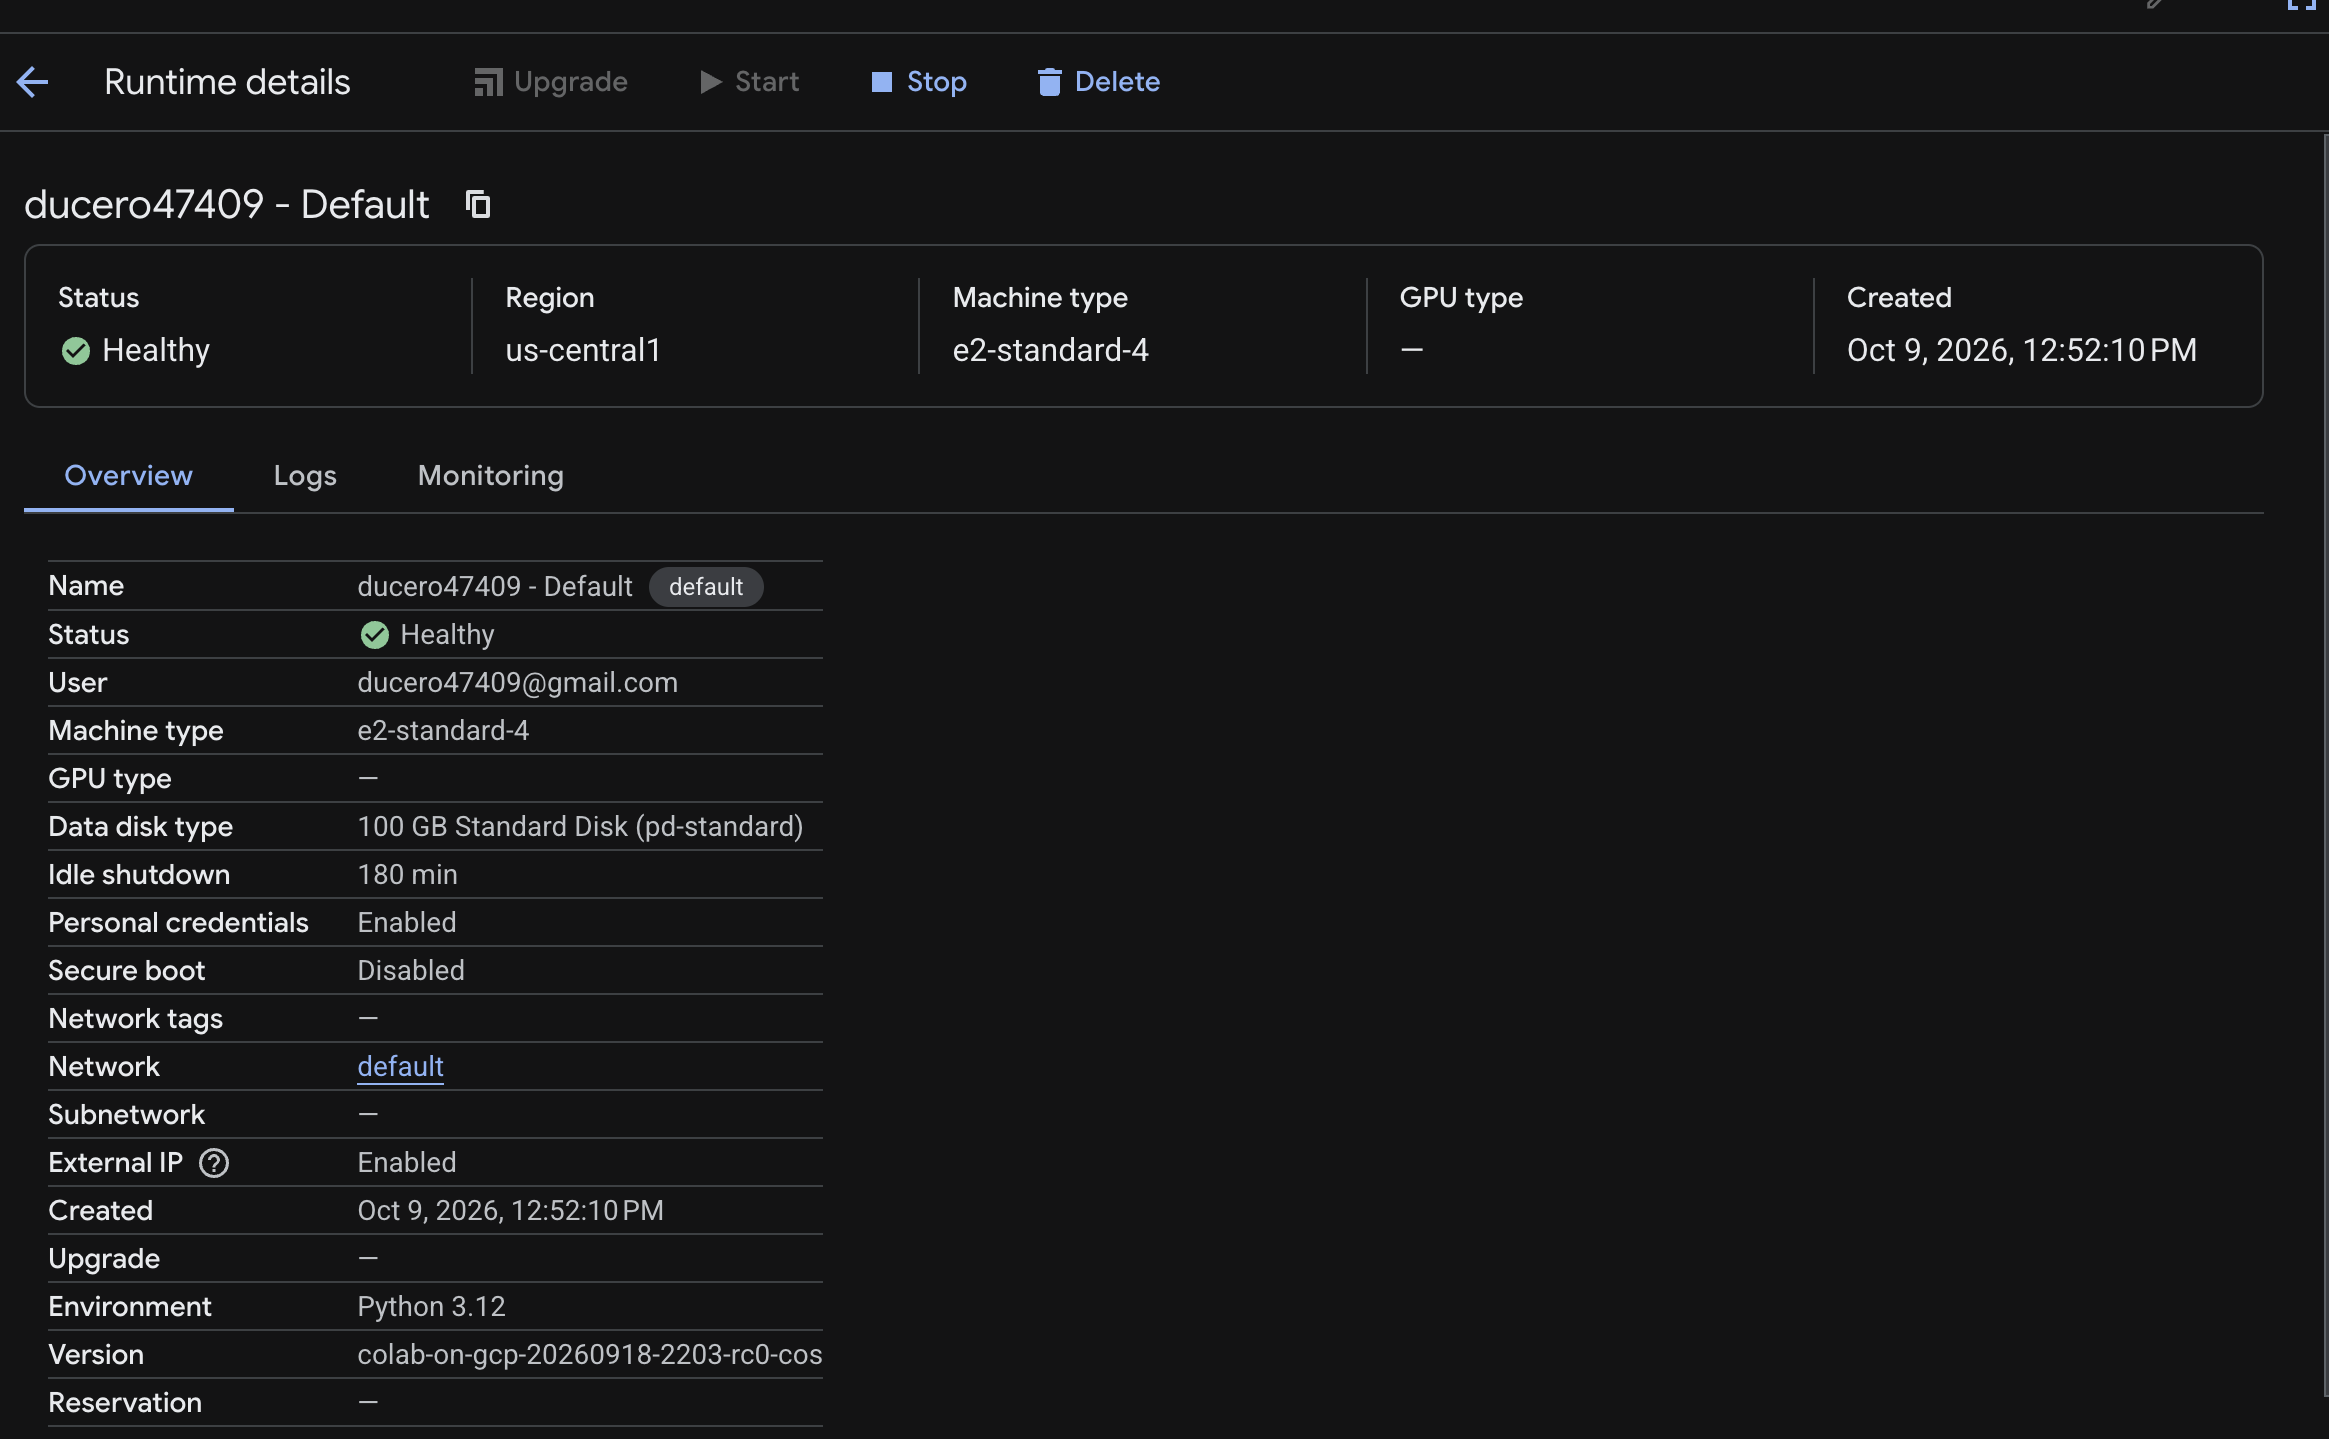managed google cloud environment.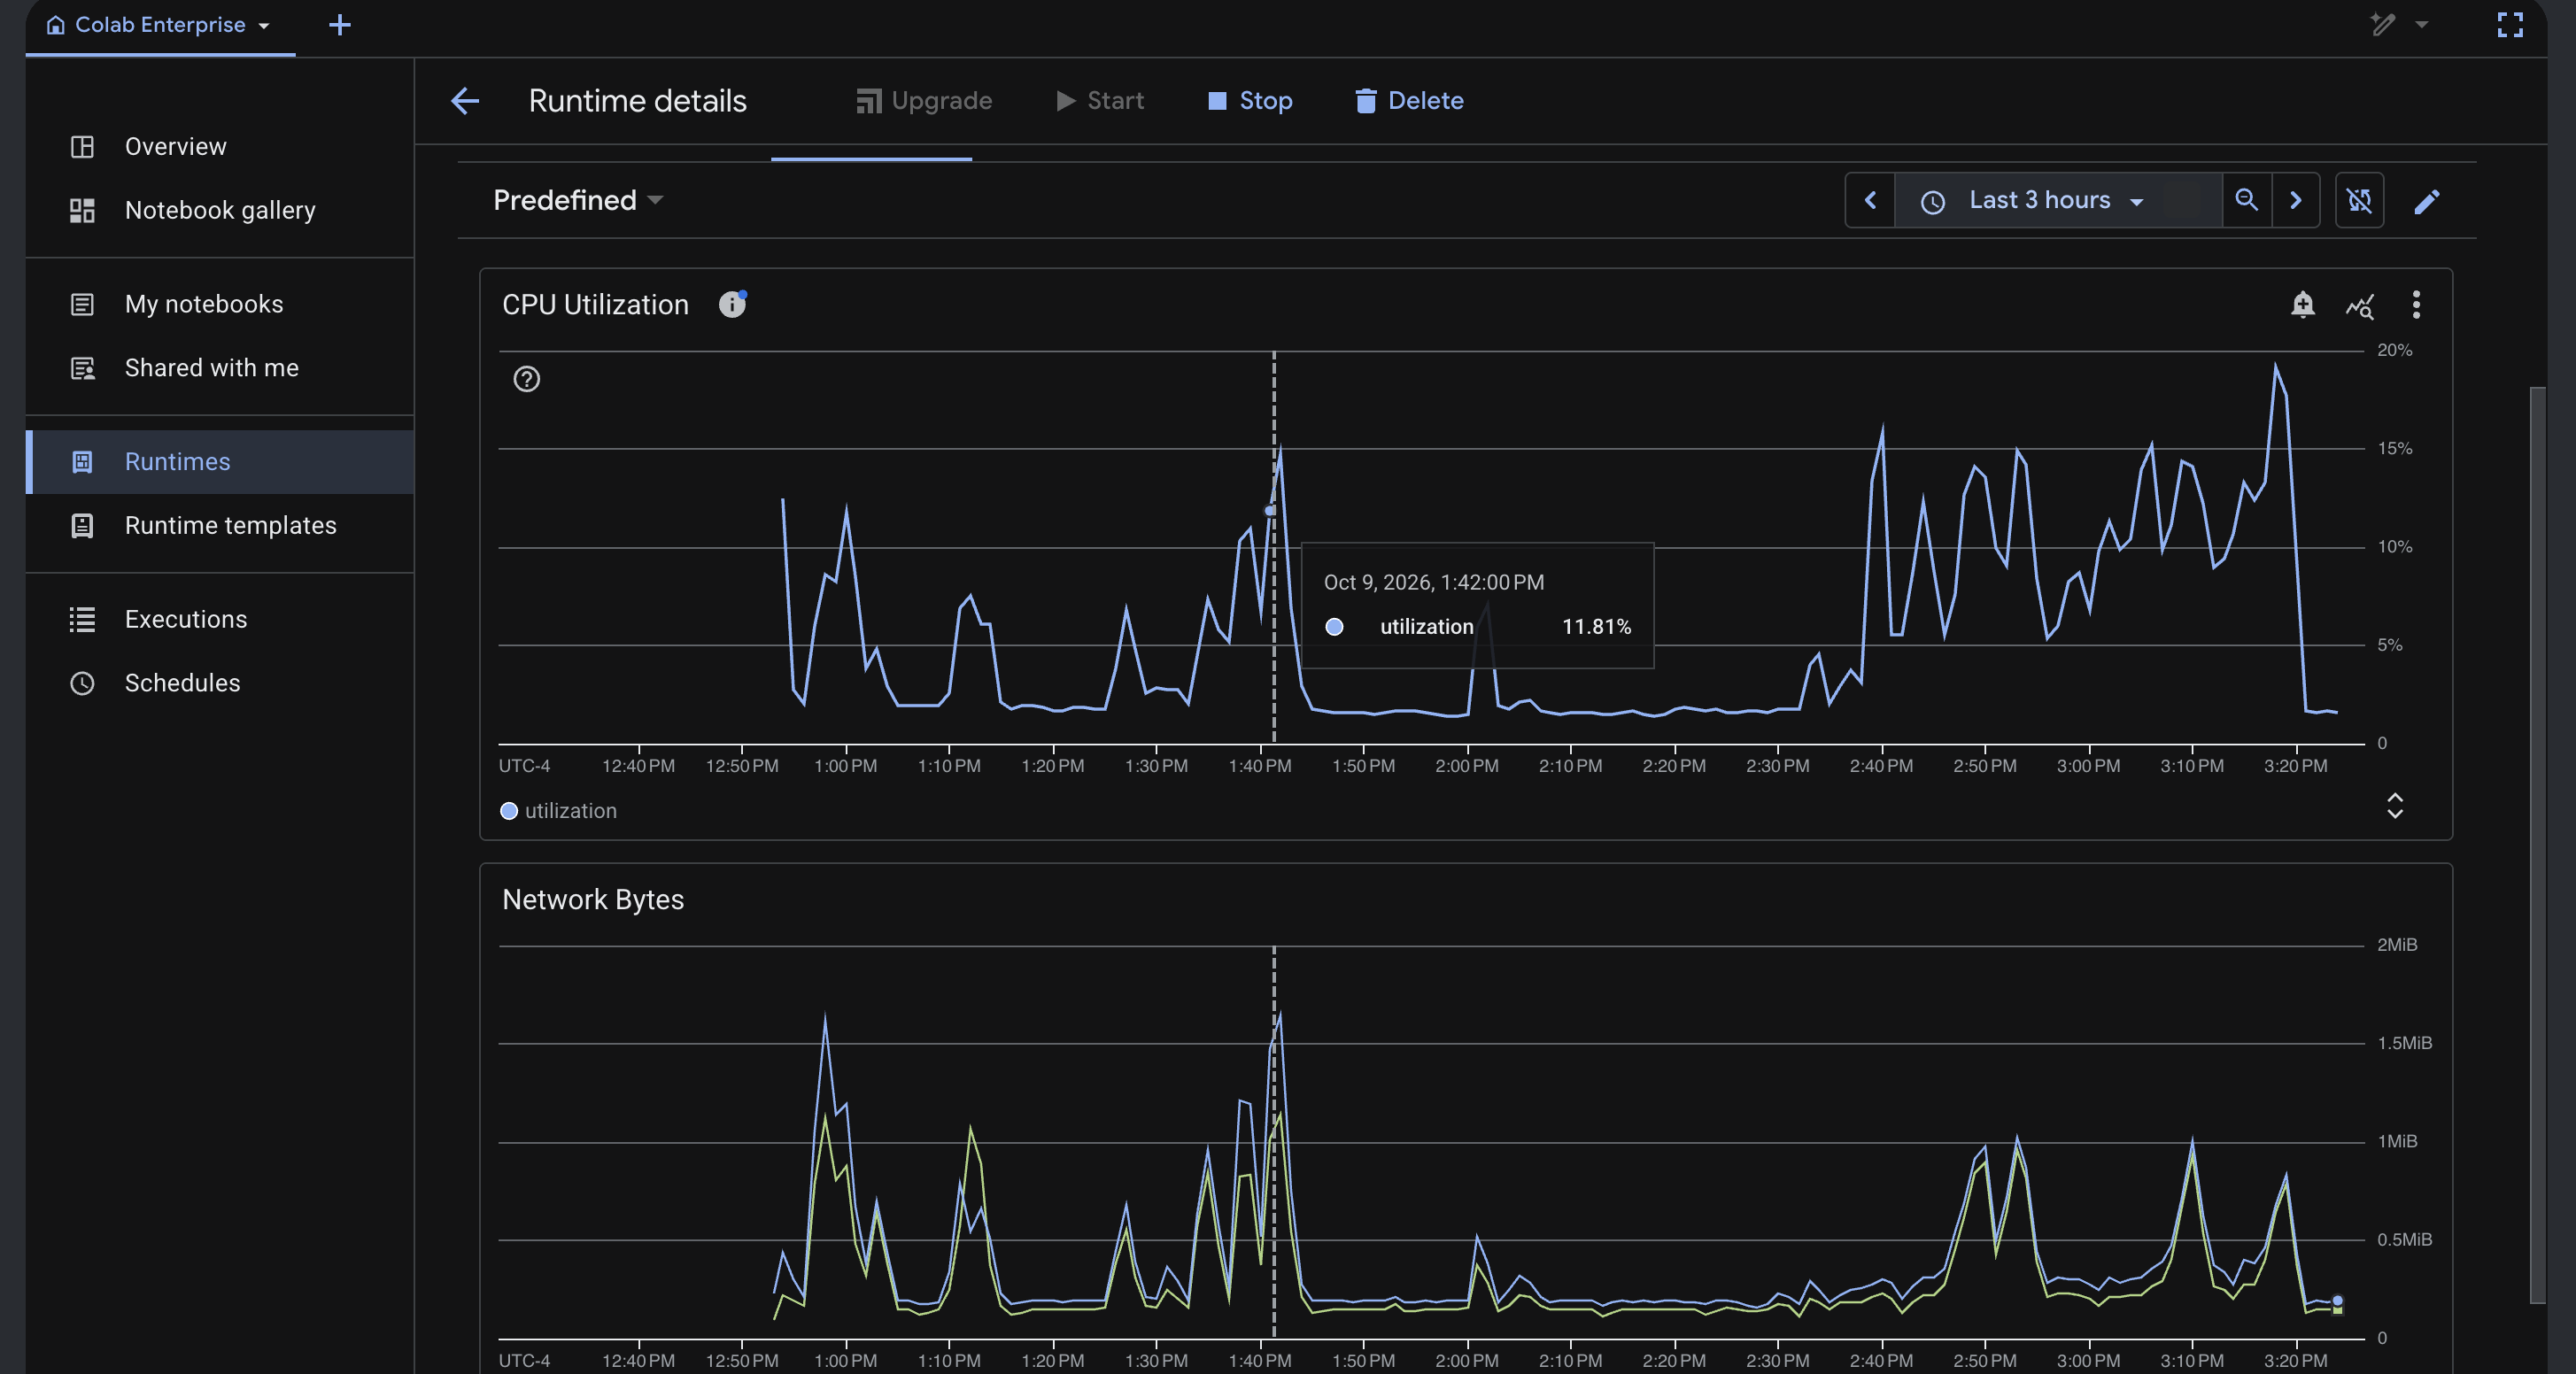